In [2]:
import pandas as pd
"""Used for data manipulation and analysis (e.g., reading CSV files, working with DataFrames)"""
import numpy as np           
"""Used for numerical operations, arrays, and mathematical functions"""
import seaborn as sns         
"""Used for data visualization (especially statistical plots like heatmaps, histograms, etc.)"""
import matplotlib.pyplot as plt  
"""Used for creating plots and graphs (line plots, bar charts, scatter plots, etc.)"""
from sklearn.model_selection import train_test_split  
"""Used to split dataset into training and testing sets"""
from sklearn.svm import SVC  
"""Support Vector Classification model from scikit-learn"""
from sklearn.metrics import accuracy_score  
"""Used to evaluate classification model accuracy"""
import pickle                 
"""Used for saving (serializing) and loading (deserializing) Python objects (e.g., ML models)"""



'Used for saving (serializing) and loading (deserializing) Python objects (e.g., ML models)'

In [3]:
df = pd.read_csv("data.csv", encoding="latin-1", low_memory=False)
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [4]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [5]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,1320,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [7]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [8]:
df.describe

<bound method NDFrame.describe of       laptop_ID Company                              Product  \
0             1   Apple                          MacBook Pro   
1             2   Apple                          Macbook Air   
2             3      HP                               250 G6   
3             4   Apple                          MacBook Pro   
4             5   Apple                          MacBook Pro   
...         ...     ...                                  ...   
1298       1316  Lenovo                       Yoga 500-14ISK   
1299       1317  Lenovo                       Yoga 900-13ISK   
1300       1318  Lenovo                   IdeaPad 100S-14IBR   
1301       1319      HP  15-AC110nv (i7-6500U/6GB/1TB/Radeon   
1302       1320    Asus  X553SA-XX031T (N3050/4GB/500GB/W10)   

                TypeName  Inches                            ScreenResolution  \
0              Ultrabook    13.3          IPS Panel Retina Display 2560x1600   
1              Ultrabook    13.3     

In [9]:
print(f" rows {df.shape[0]}")
print(f" column {df.shape[1]}")

 rows 1303
 column 13


In [10]:
df.dtypes

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

In [11]:

df.count()

laptop_ID           1303
Company             1303
Product             1303
TypeName            1303
Inches              1303
ScreenResolution    1303
Cpu                 1303
Ram                 1303
Memory              1303
Gpu                 1303
OpSys               1303
Weight              1303
Price_euros         1303
dtype: int64

In [12]:
df['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [13]:
df['TypeName'].unique()

array(['Ultrabook', 'Notebook', 'Netbook', 'Gaming', '2 in 1 Convertible',
       'Workstation'], dtype=object)

In [14]:
df['laptop_ID'].unique()

array([   1,    2,    3, ..., 1318, 1319, 1320], shape=(1303,))

In [15]:
for col in df.columns:
    print(col)

laptop_ID
Company
Product
TypeName
Inches
ScreenResolution
Cpu
Ram
Memory
Gpu
OpSys
Weight
Price_euros


In [16]:
df = df.drop('laptop_ID', axis=1)


In [17]:
df = df.drop('Weight', axis=1)


In [18]:
df.rename(columns={'Price_euros': 'price'}, inplace=True)

In [19]:
df.head(1)

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,price
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1339.69


In [20]:
df.to_csv('1.csv',index= False,header = True)

In [21]:
# def changefloat(cols):
#     for i in cols:
#         df[i] = df[i].astype('int64')
# columns = ['Inches','price']
# changefloat(columns)
    

In [22]:
df.head(1)

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,price
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1339.69


In [23]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'price'],
      dtype='object')

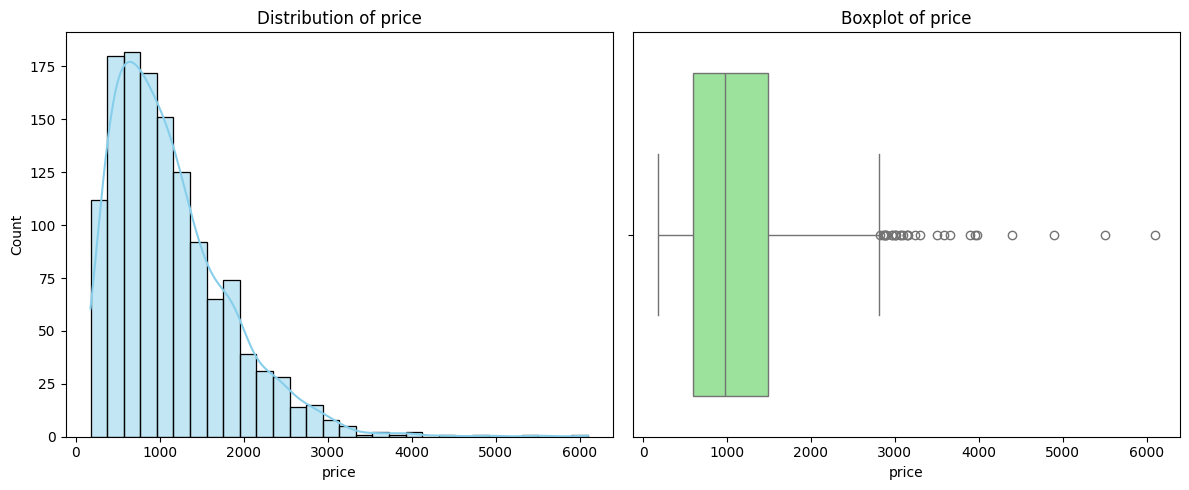

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric(data, column):
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[column], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {column}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[column], color='lightgreen')
    plt.title(f'Boxplot of {column}')

    plt.tight_layout()
    plt.show()

# Correct usage
plot_numeric(df, 'price')

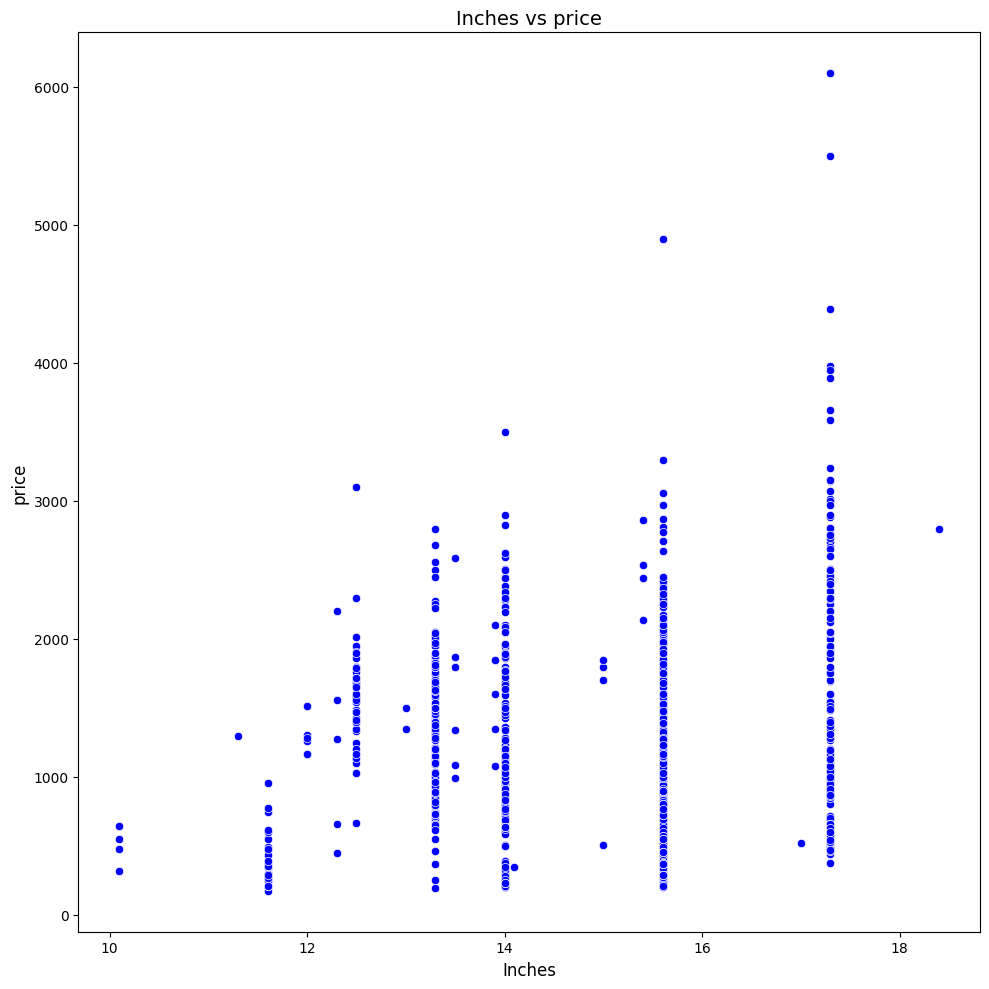

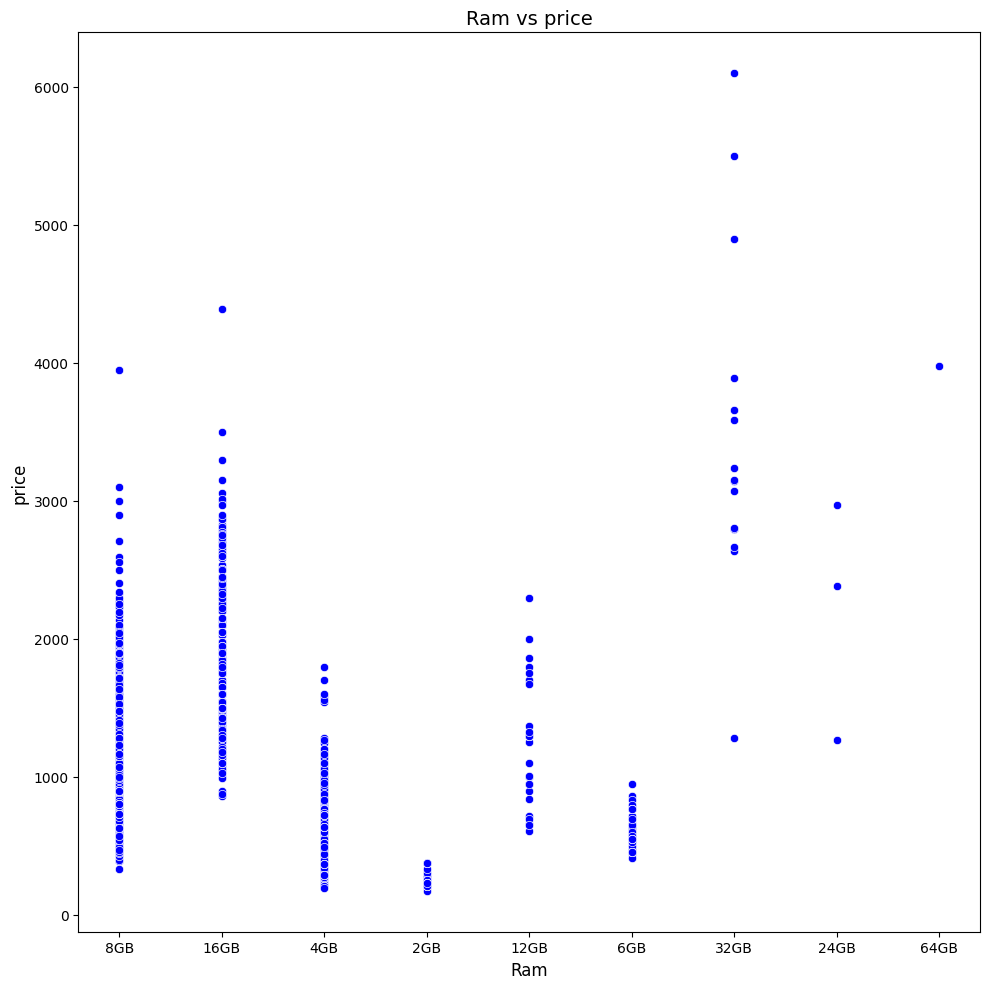

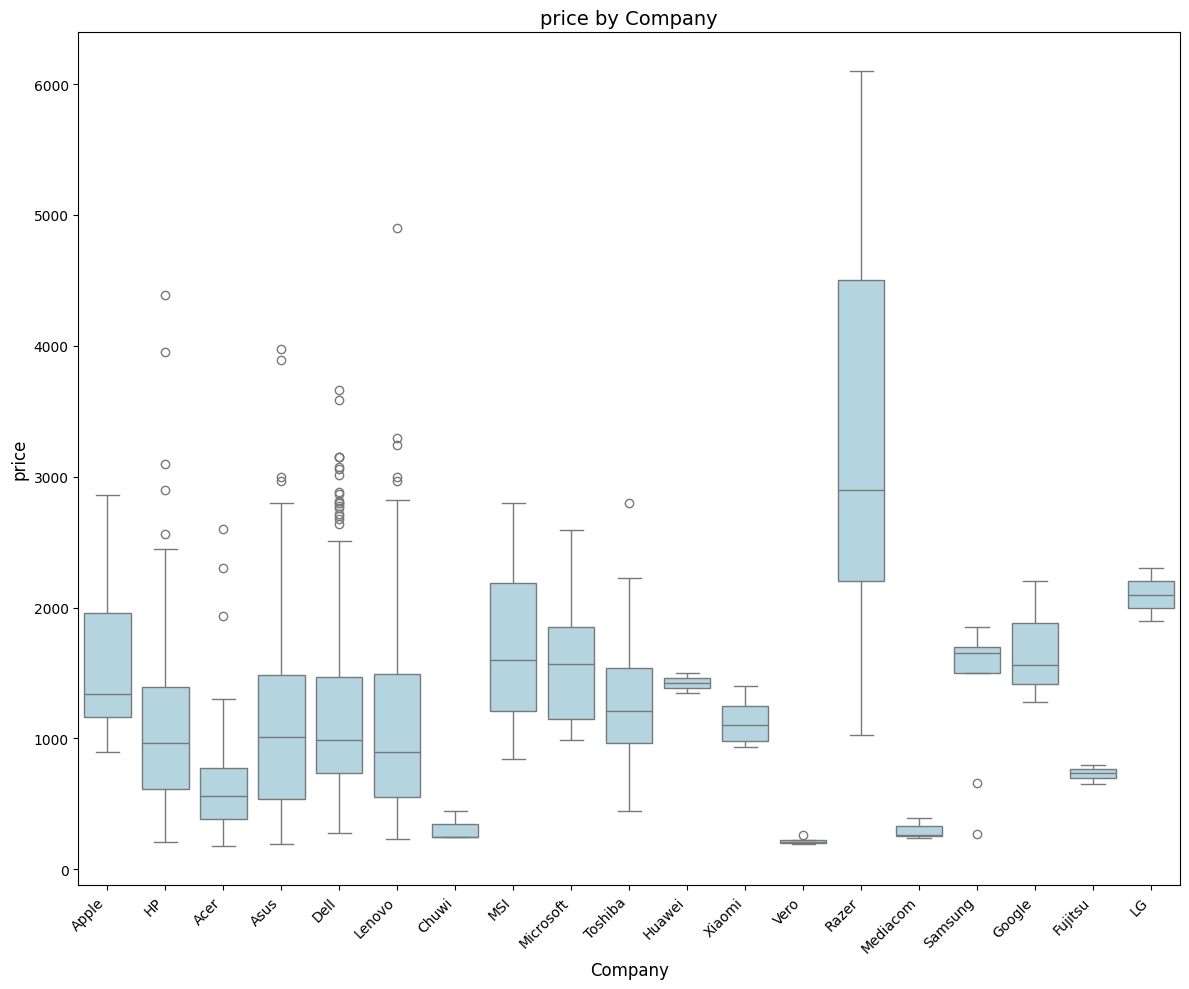

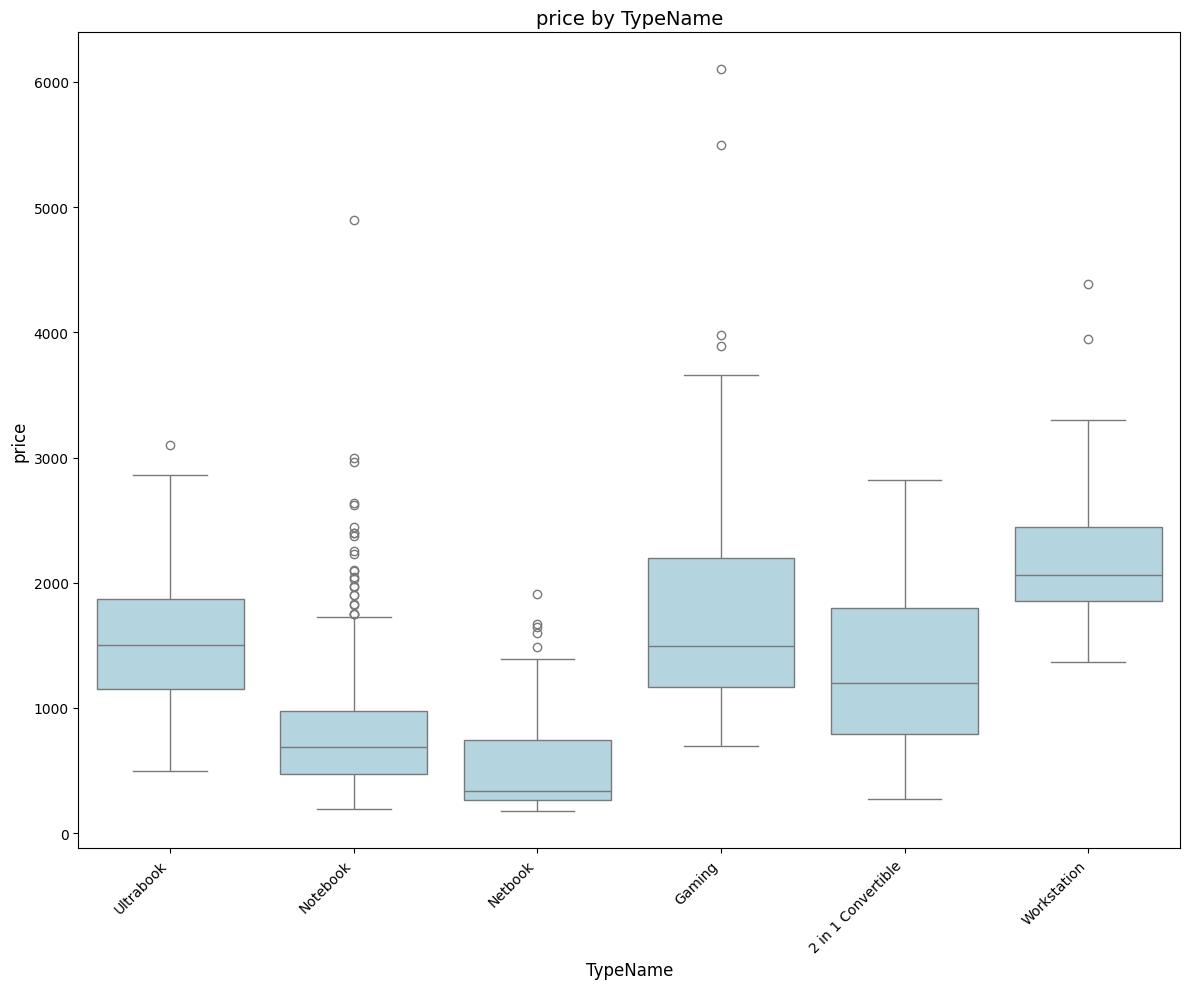

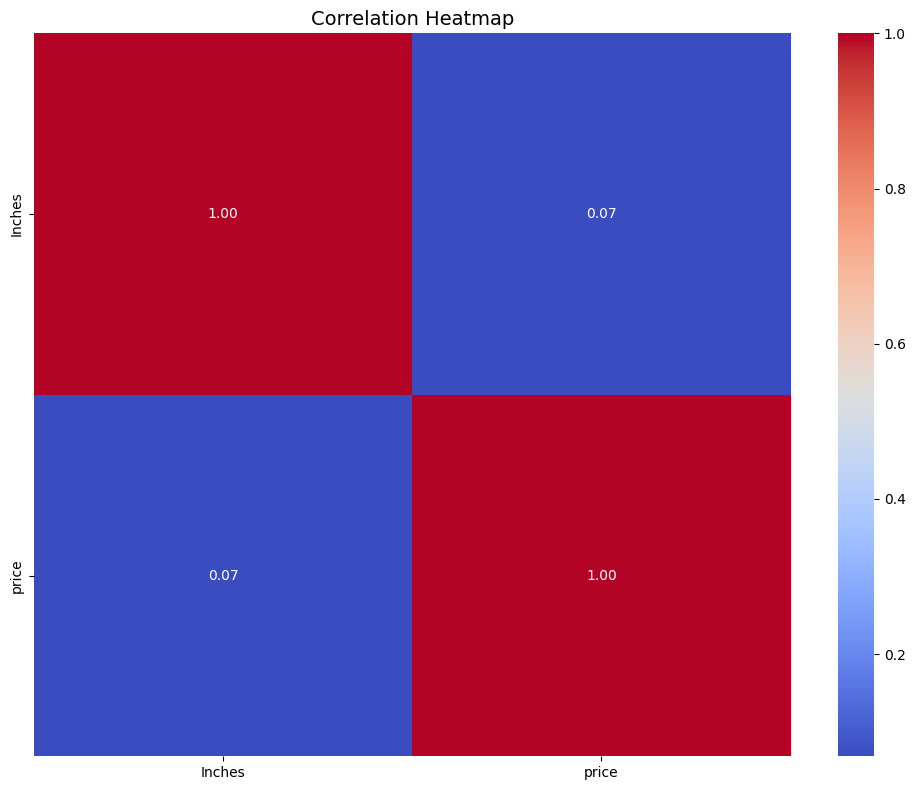

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric vs numeric scatter plot
def scatter_plot(data, x, y, width=10, height=10, point_color='b', title=None):
    plt.figure(figsize=(width, height))
    sns.scatterplot(x=data[x], y=data[y], color=point_color)
    plt.title(title or f'{x} vs {y}', fontsize=14)
    plt.xlabel(x, fontsize=12)
    plt.ylabel(y, fontsize=12)
    plt.tight_layout()  # fixes overlapping
    plt.show()

# Box plot for categorical-like numeric columns
def box_plot(data, x, y, width=12, height=10, box_color='lightblue', rotation=45, title=None):
    plt.figure(figsize=(width, height))
    sns.boxplot(x=data[x], y=data[y], color=box_color)
    plt.title(title or f'{y} by {x}', fontsize=14)
    plt.xlabel(x, fontsize=12)
    plt.ylabel(y, fontsize=12)
    plt.xticks(rotation=rotation, ha='right')  # rotate long category names neatly
    plt.tight_layout()  # prevents overlapping
    plt.show()

# Correlation heatmap
def correlation_heatmap(data, width=10, height=8, cmap='coolwarm', fmt=".2f", annot=True, title='Correlation Heatmap'):
    plt.figure(figsize=(width, height))
    corr = data.corr(numeric_only=True)
    sns.heatmap(corr, annot=annot, cmap=cmap, fmt=fmt)
    plt.title(title, fontsize=14)
    plt.tight_layout()  # prevents overlapping labels
    plt.show()


# Example usage
scatter_plot(df, 'Inches', 'price')
scatter_plot(df, 'Ram', 'price')
# scatter_plot(df, 'Cpu', 'price')  
# scatter_plot(df, 'Memory', 'price')

box_plot(df, 'Company', 'price')
box_plot(df, 'TypeName', 'price')
# box_plot(df, 'Product', 'price')

correlation_heatmap(df)

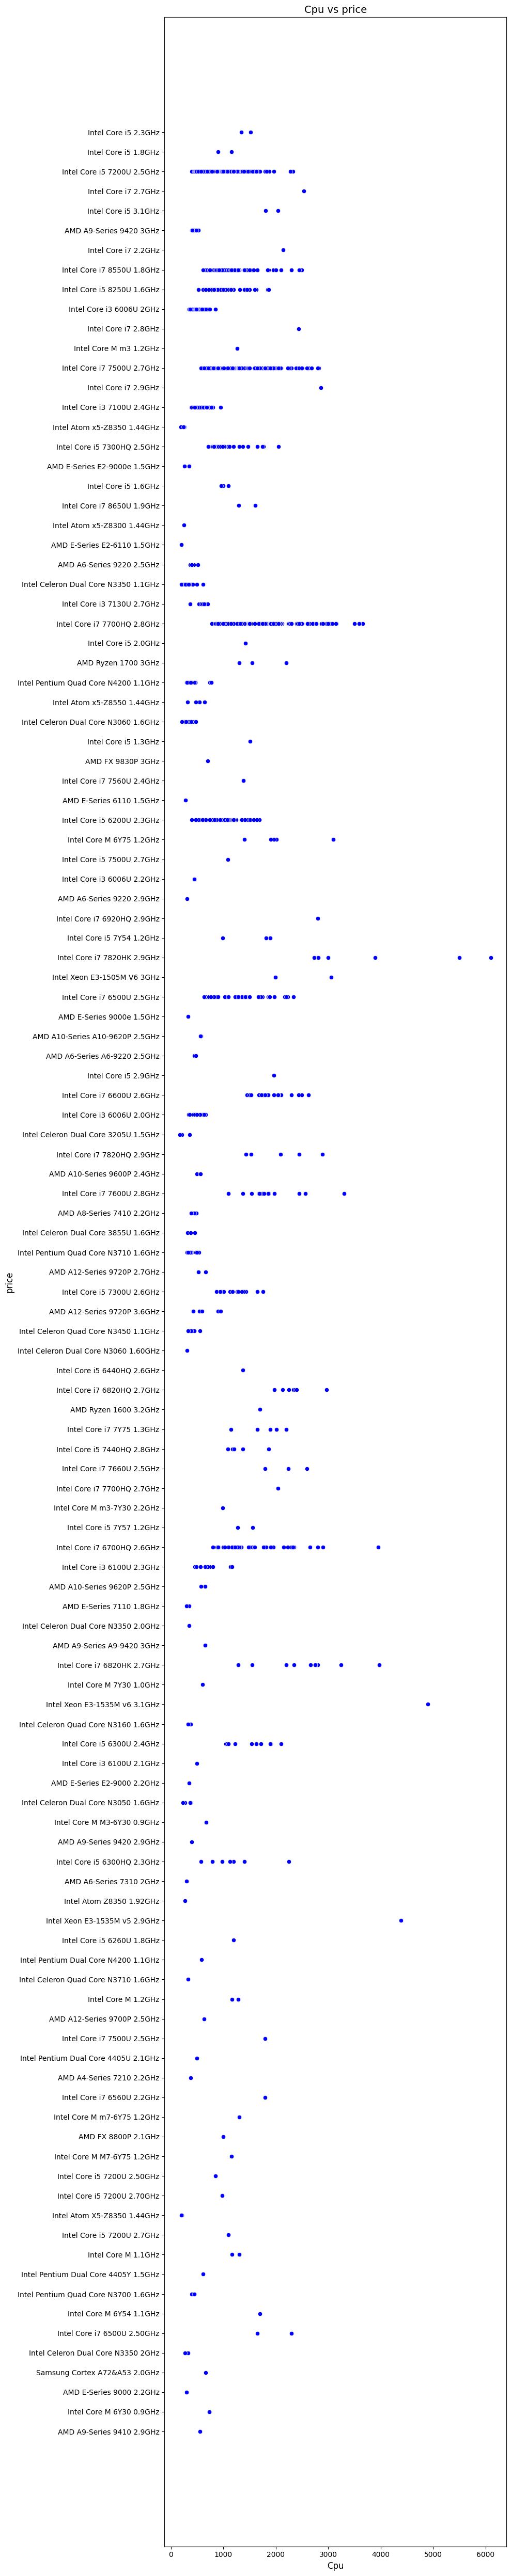

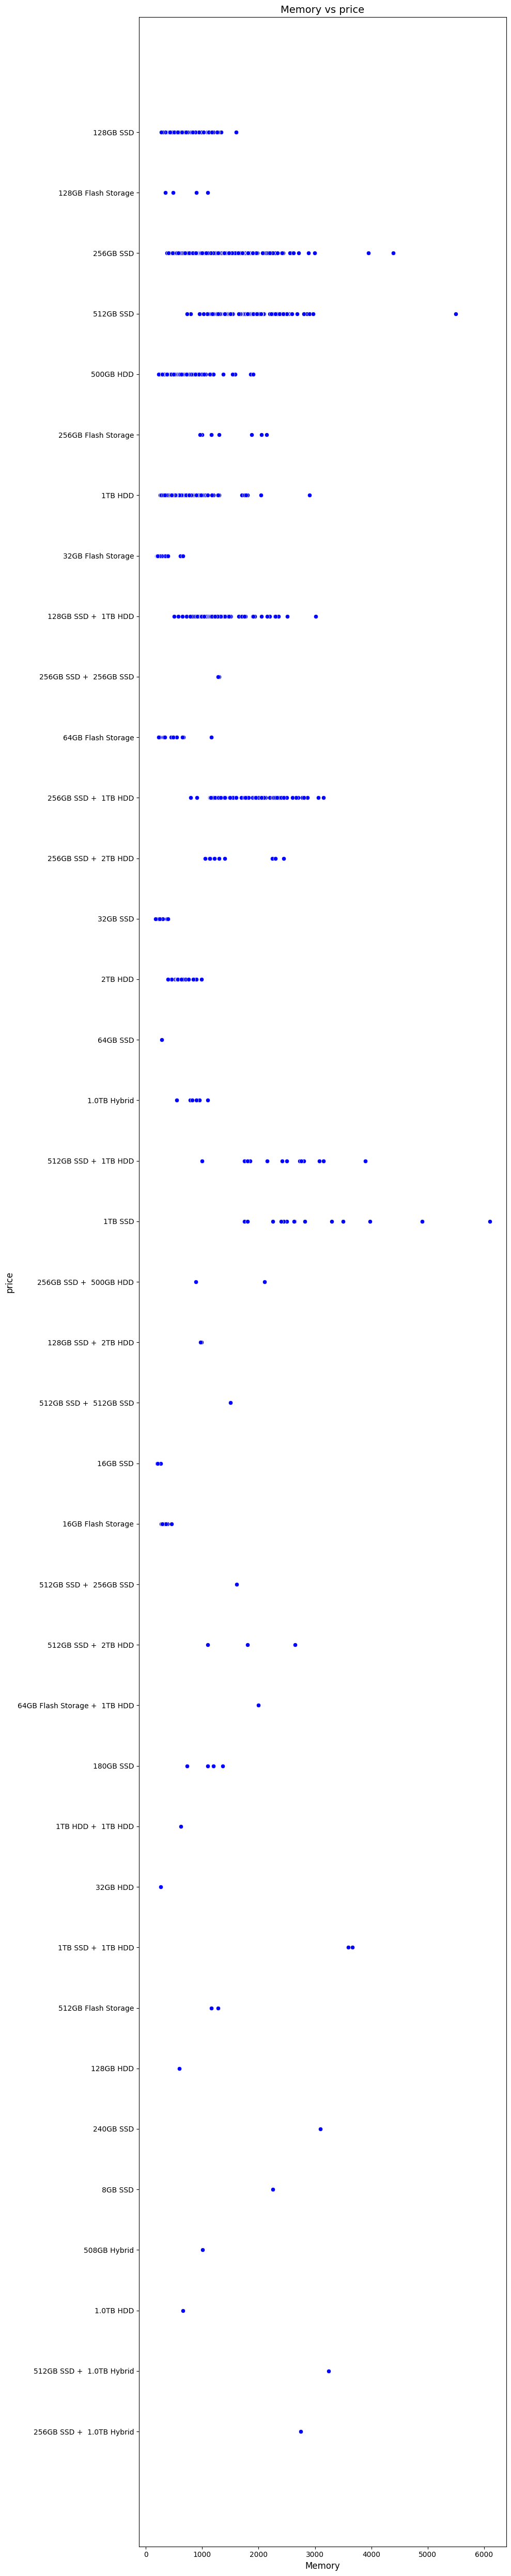

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric vs numeric scatter plot
def scatter_plot(data, x, y, width=10, height=50, point_color='b', title=None):
    plt.figure(figsize=(width, height))
    sns.scatterplot(x=data[y], y=data[x], color=point_color)
    plt.title(title or f'{x} vs {y}', fontsize=14)
    plt.xlabel(x, fontsize=12)
    plt.ylabel(y, fontsize=12)
    plt.tight_layout()  # fixes overlapping
    plt.show()

scatter_plot(df, 'Cpu', 'price')  
scatter_plot(df, 'Memory', 'price')





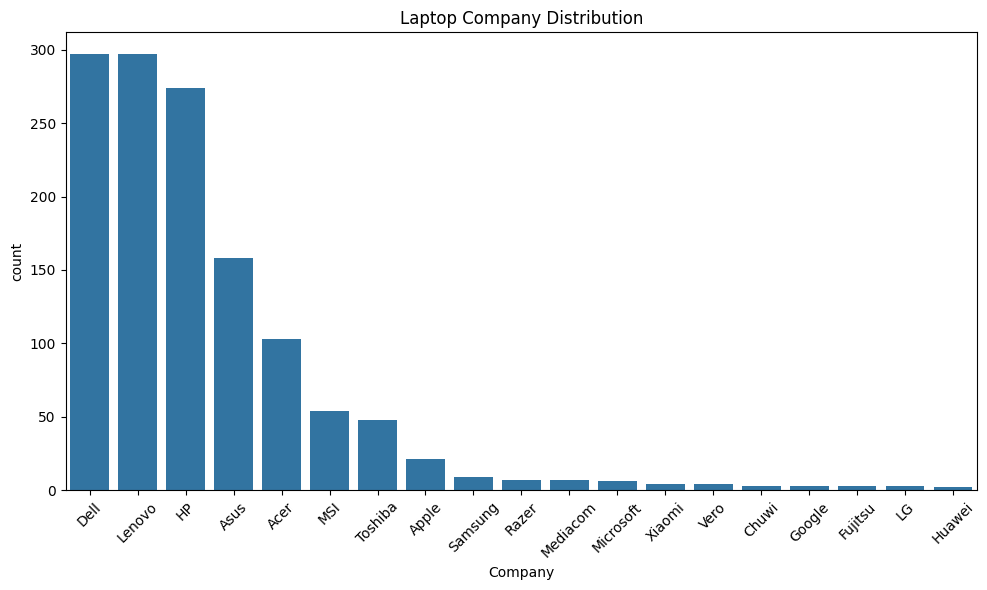

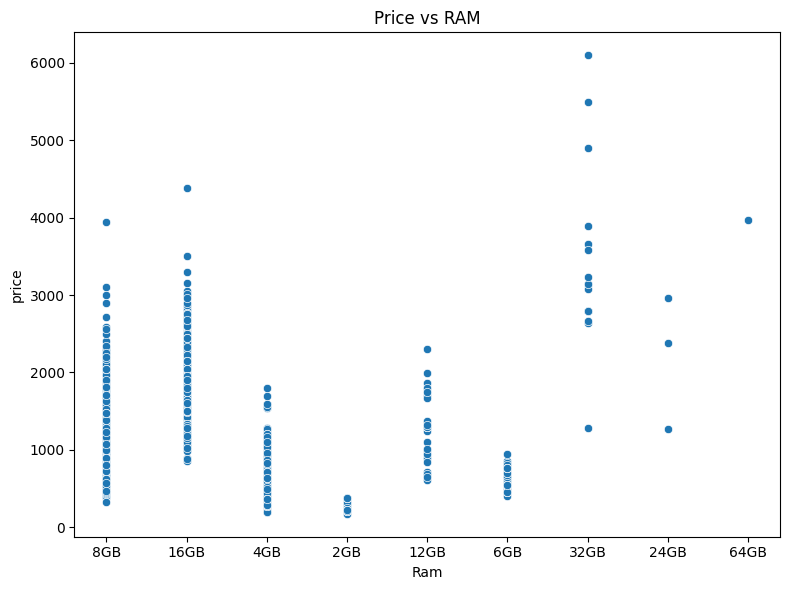

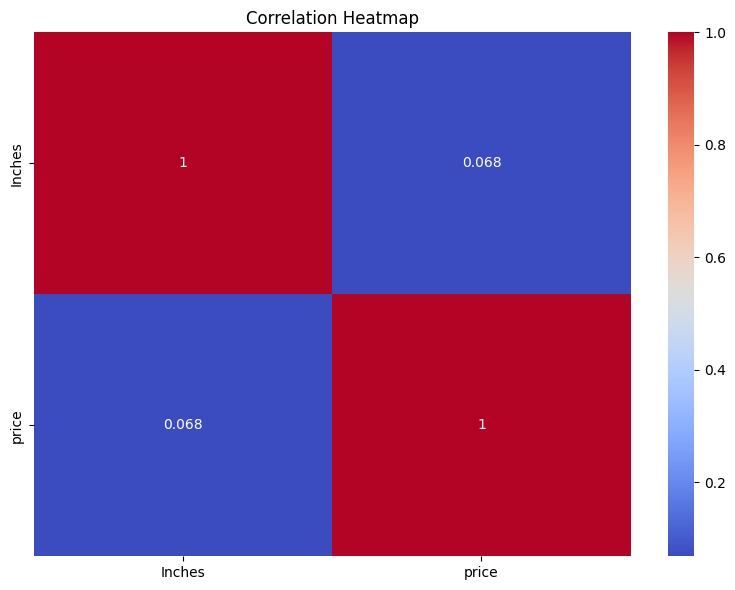

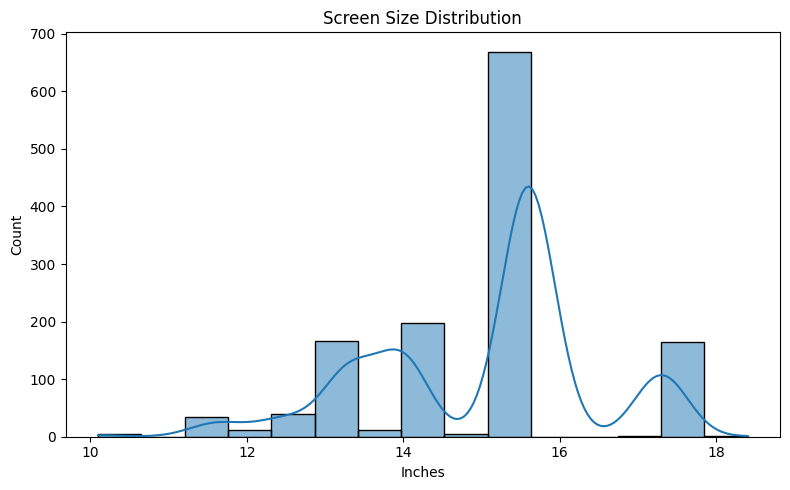

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Company distribution
def plot_company_distribution(data, column='Company', width=10, height=6, rotation=45, title='Laptop Company Distribution'):
    plt.figure(figsize=(width, height))
    sns.countplot(data=data, x=column, order=data[column].value_counts().index)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

# Price vs RAM scatter plot
def plot_price_vs_ram(data, x='Ram', y='price', width=8, height=6, title='Price vs RAM'):
    plt.figure(figsize=(width, height))
    sns.scatterplot(data=data, x=x, y=y)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Correlation heatmap
def plot_correlation_heatmap(data, width=8, height=6, cmap='coolwarm', annot=True, title='Correlation Heatmap'):
    plt.figure(figsize=(width, height))
    numeric_data = data.select_dtypes(include='number')
    sns.heatmap(numeric_data.corr(), annot=annot, cmap=cmap)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Screen size distribution
def plot_screen_size_distribution(data, column='Inches', bins=15, kde=True, width=8, height=5, title='Screen Size Distribution'):
    plt.figure(figsize=(width, height))
    sns.histplot(data[column], bins=bins, kde=kde)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ===== Usage =====
plot_company_distribution(df)
plot_price_vs_ram(df)
plot_correlation_heatmap(df)
plot_screen_size_distribution(df)

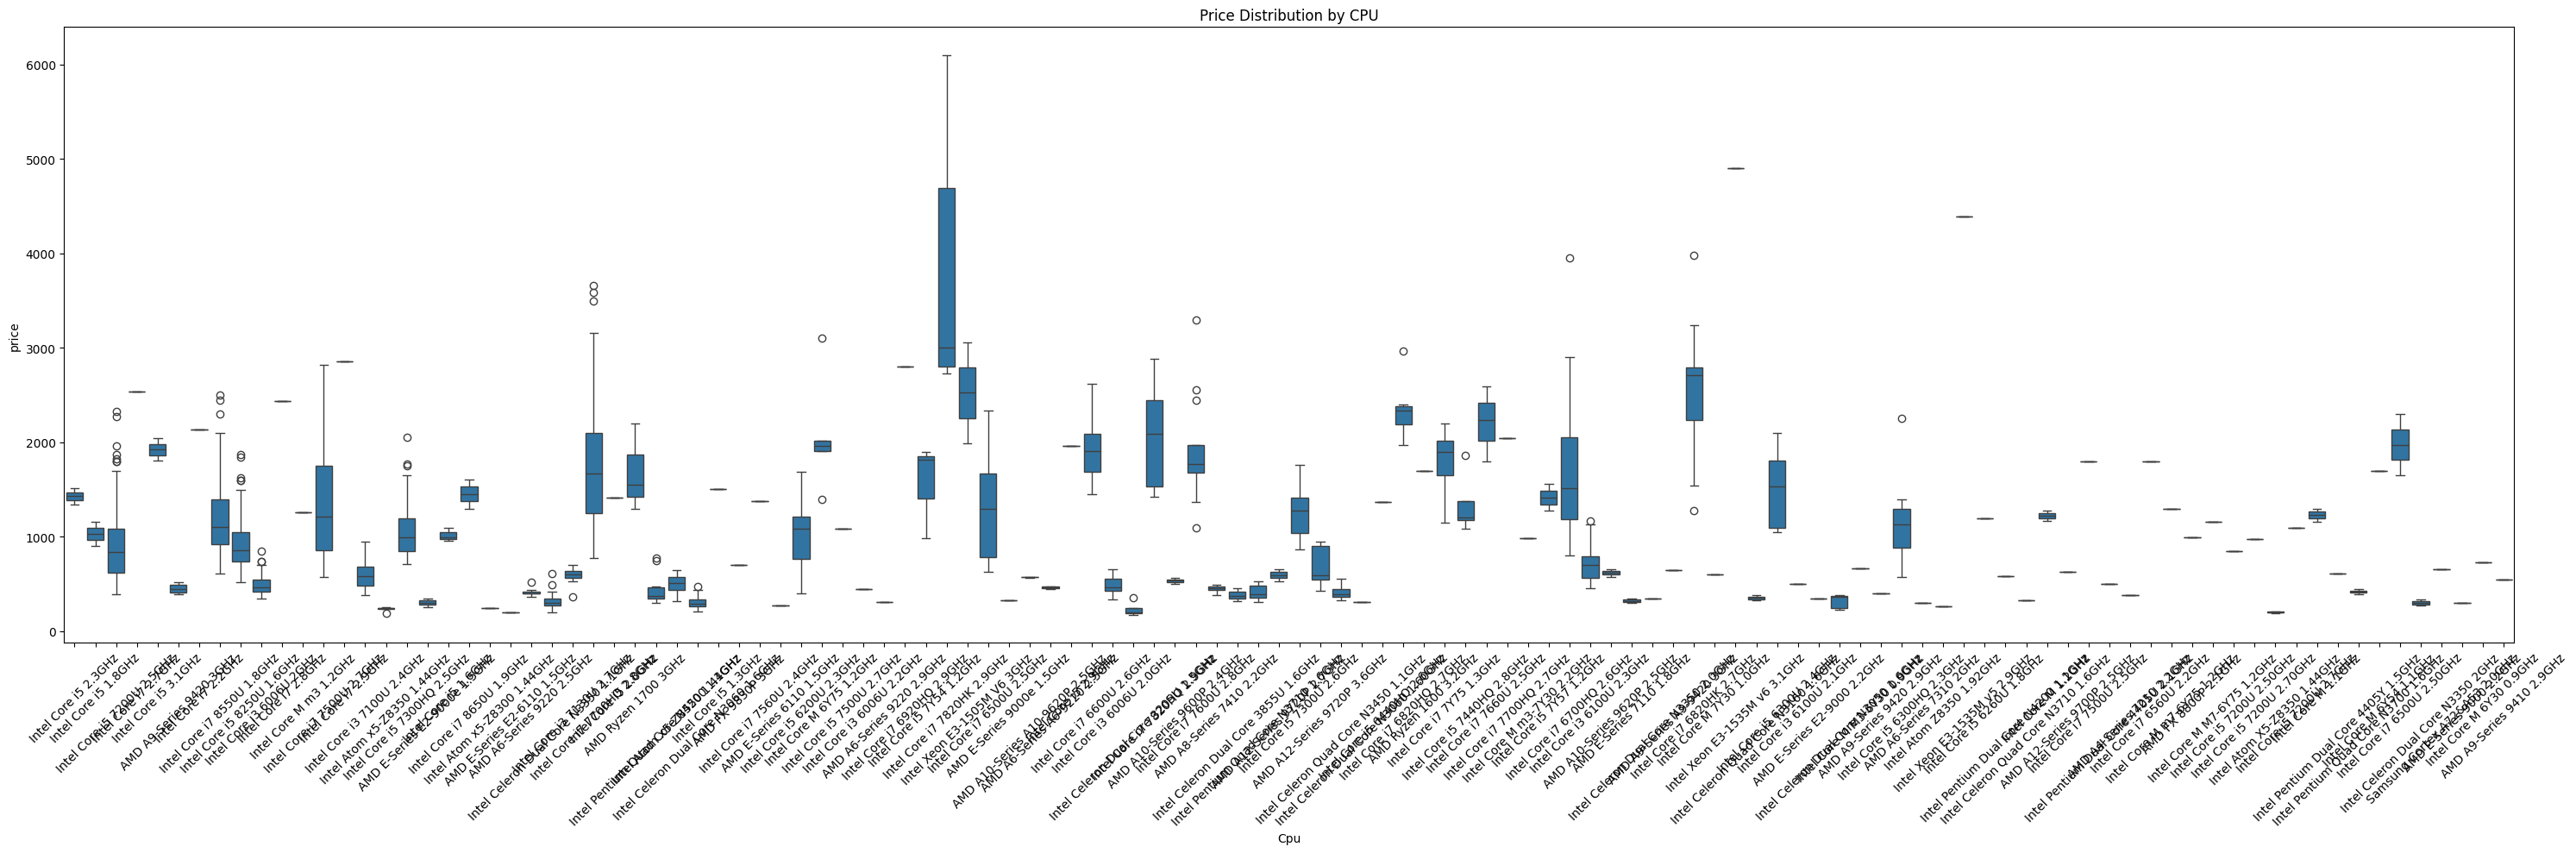

In [28]:
# Price by CPU box plot
def plot_cpu_price_box(data, x='Cpu', y='price', width=30, height=10, rotation=45, title='Price Distribution by CPU'):
    plt.figure(figsize=(width, height))
    sns.boxplot(data=data, x=x, y=y)
    plt.xticks(rotation=rotation)
    plt.title(title)
    plt.tight_layout()
    plt.show()
plot_cpu_price_box(df)


In [29]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,price
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1803.60


In [30]:
df.isnull().sum()

Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
price               0
dtype: int64

In [31]:
df.dtypes

Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
price               float64
dtype: object

In [32]:
def changefloat(cols):
    for i in cols:
        df[i] = df[i].astype('int64')
columns = ['Inches','price']
changefloat(columns)
    

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
def changeobjtoint(cols):
    for i in cols:
        data = pd.DataFrame({i:df[i].unique()})
        data_LE = LabelEncoder()
        data_LE.fit(np.ravel(data))
        # data_LE.fit(data)
        df[i] = data_LE.transform(df[i])
columns = ['Company', 'Product', 'TypeName','ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'OpSys']
changeobjtoint(columns)
    

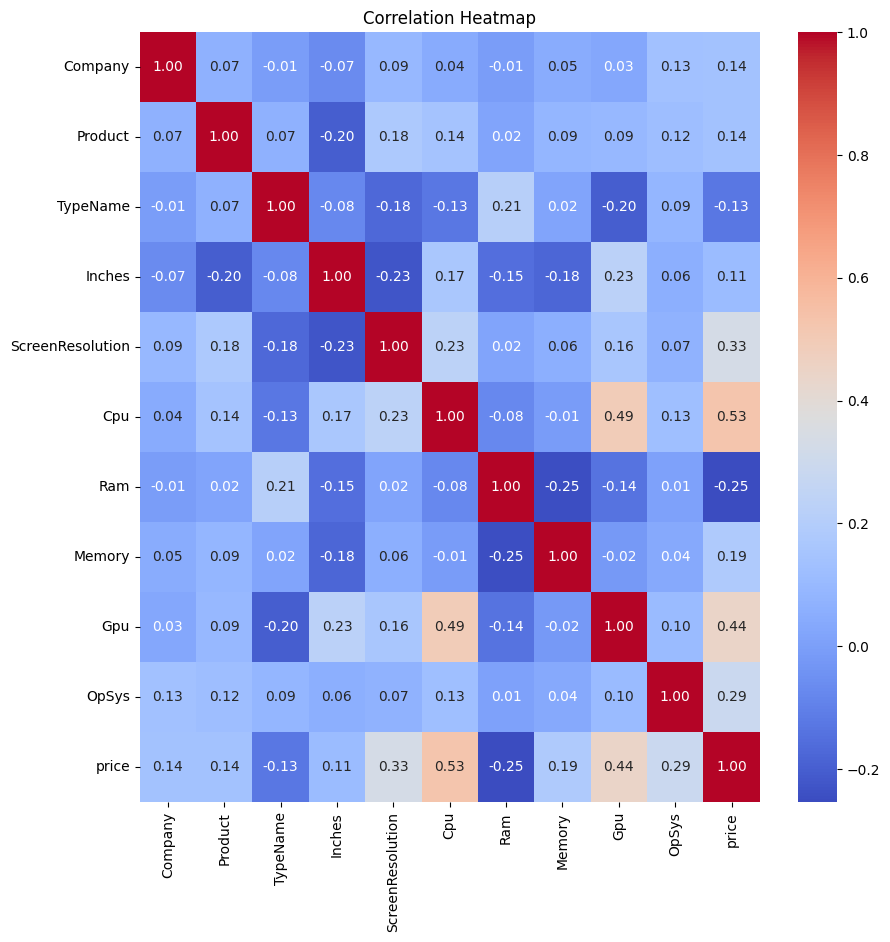

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def correlation_heatmap(data, width=10, height=10, cmap='coolwarm', fmt=".2f", annot=True, title='Correlation Heatmap'):
    plt.figure(figsize=(width, height))
    corr = data.corr(numeric_only=True)
    sns.heatmap(corr, annot=annot, cmap=cmap, fmt=fmt)
    plt.title(title)
    plt.show()


correlation_heatmap(df)

In [46]:
import pandas as pd
from scipy.stats import skew

# Load dataset
file_path = "preprocessed.csv"
data = pd.read_csv(file_path)

# Clean column names
data.columns = data.columns.str.strip()

# Select column (example: price)
col = data['price']

# Calculate skewness
skewness_value = skew(col)

print("Skewness:", skewness_value)

Skewness: 1.5190017378752938


In [47]:
import pandas as pd
from scipy.stats import kurtosis

# Load dataset
file_path = "preprocessed.csv"
data = pd.read_csv(file_path)

# Clean column names
data.columns = data.columns.str.strip()

# Select column (example: price)
col = data['price']

# Calculate kurtosis
kurtosis_value = kurtosis(col)

print("Kurtosis:", kurtosis_value)

Kurtosis: 4.349559546999046


Skewness: 1.5190017378752938
Kurtosis: 4.349559546999046


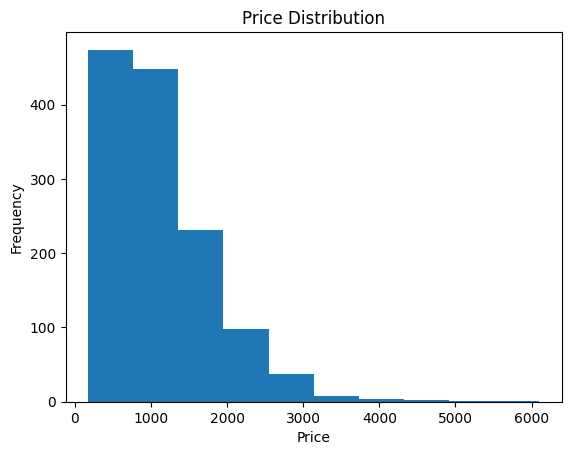

In [48]:
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

# Load dataset
file_path = "preprocessed.csv"
data = pd.read_csv(file_path)

# Remove any extra spaces in column names (important fix)
data.columns = data.columns.str.strip()

# Select numeric column (example: price)
col = data['price']

# Calculate skewness
skewness_value = skew(col)

# Calculate kurtosis
kurtosis_value = kurtosis(col)

print("Skewness:", skewness_value)
print("Kurtosis:", kurtosis_value)

# Optional: visualize distribution
plt.hist(col, bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [37]:
df.to_csv('preprocessed.csv',index= False,header = True)

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load data
data = pd.read_csv('preprocessed.csv')

# Features and target
X = data.drop(columns=['price'])
y = data['price']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Initialize model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R^2 Score: {r2}')

MSE: 83536.0421617072
R^2 Score: 0.8355305371652617


In [40]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f'XGBoost R^2: {r2_score(y_test, y_pred_xgb)}')

XGBoost R^2: 0.85993492603302


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load data
data = pd.read_csv('preprocessed.csv')

# Features and target
X = data.drop(columns=['price'])
y = data['price']

# Split data (train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2 * 100  # Convert to percentage

# Overall Summary
print("----- Random Forest Regression Summary -----")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score (Decimal): {r2:.4f}")
print(f"Accuracy (Percentage): {accuracy_percent:.2f}%")
print("--------------------------------------------")

----- Random Forest Regression Summary -----
Mean Squared Error (MSE): 83536.04
R^2 Score (Decimal): 0.8355
Accuracy (Percentage): 83.55%
--------------------------------------------


In [42]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load your data
data = pd.read_csv('preprocessed.csv')

# Features and target
X = data.drop(columns=['price'])
y = data['price']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Create a comparison table
comparison = pd.DataFrame({
    'Original Price': y_test.values,
    'Predicted Price': y_pred,
    'Absolute Error': abs(y_test.values - y_pred),
    'Percentage Error (%)': abs(y_test.values - y_pred) / y_test.values * 100
})

# Reset index for neat display
comparison = comparison.reset_index(drop=True)

# Evaluate overall performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2 * 100

# Print overall metrics
print("----- Random Forest Regression Summary -----")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score (Decimal): {r2:.4f}")
print(f"Accuracy (Percentage): {accuracy_percent:.2f}%")
print("--------------------------------------------\n")

# Display comparison table
print("Original vs Predicted Prices:")
print(comparison)

----- Random Forest Regression Summary -----
Mean Squared Error (MSE): 83536.04
R^2 Score (Decimal): 0.8355
Accuracy (Percentage): 83.55%
--------------------------------------------

Original vs Predicted Prices:
     Original Price  Predicted Price  Absolute Error  Percentage Error (%)
0              1672         1190.580         481.420             28.793062
1              1149         1061.910          87.090              7.579634
2               499          542.280          43.280              8.673347
3               899          897.630           1.370              0.152392
4              1244         1371.480         127.480             10.247588
..              ...              ...             ...                   ...
256            1299         1265.590          33.410              2.571978
257            1045         1090.155          45.155              4.321053
258            2884         2586.930         297.070             10.300624
259            1943         1971.230

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load your data
data = pd.read_csv('preprocessed.csv')

# Features and target
X = data.drop(columns=['price'])
y = data['price']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred = xgb_model.predict(X_test)

# Create comparison table
comparison = pd.DataFrame({
    'Original Price': y_test.values,
    'Predicted Price': y_pred,
    'Absolute Error': abs(y_test.values - y_pred),
    'Percentage Error (%)': abs(y_test.values - y_pred) / y_test.values * 100
})

# Reset index for neat display
comparison = comparison.reset_index(drop=True)

# Evaluate overall performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2 * 100

# Print overall metrics
print("----- XGBoost Regression Summary -----")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score (Decimal): {r2:.4f}")
print(f"Accuracy (Percentage): {accuracy_percent:.2f}%")
print("--------------------------------------\n")

# Display comparison table
print("Original vs Predicted Prices:")
print(comparison)

----- XGBoost Regression Summary -----
Mean Squared Error (MSE): 71140.76
R^2 Score (Decimal): 0.8599
Accuracy (Percentage): 85.99%
--------------------------------------

Original vs Predicted Prices:
     Original Price  Predicted Price  Absolute Error  Percentage Error (%)
0              1672      1182.273682      489.726318             29.289852
1              1149       957.232483      191.767517             16.689949
2               499       475.697205       23.302795              4.669899
3               899       901.424133        2.424133              0.269648
4              1244      1306.889771       62.889771              5.055448
..              ...              ...             ...                   ...
256            1299      1115.295898      183.704102             14.141963
257            1045      1029.824219       15.175781              1.452228
258            2884      2478.029053      405.970947             14.076663
259            1943      2226.152588      283.15

In [44]:
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load your data
data = pd.read_csv('preprocessed.csv')

# Features and target
X = data.drop(columns=['price'])
y = data['price']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize CatBoost Regressor without specifying categorical features
cat_model = CatBoostRegressor(
    n_estimators=100,
    random_state=42,
    verbose=0
)

# Train model (all features treated as numeric)
cat_model.fit(X_train, y_train)

# Predict on test set
y_pred = cat_model.predict(X_test)

# Create comparison table
comparison = pd.DataFrame({
    'Original Price': y_test.values,
    'Predicted Price': y_pred,
    'Absolute Error': abs(y_test.values - y_pred),
    'Percentage Error (%)': abs(y_test.values - y_pred) / y_test.values * 100
}).reset_index(drop=True)

# Evaluate overall performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2 * 100

# Print summary
print("----- CatBoost Regression (All Features Numeric) -----")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score (Decimal): {r2:.4f}")
print(f"Accuracy (Percentage): {accuracy_percent:.2f}%")
print("------------------------------------------------------\n")

# Display comparison table
print("Original vs Predicted Prices:")
print(comparison)

----- CatBoost Regression (All Features Numeric) -----
Mean Squared Error (MSE): 74912.93
R^2 Score (Decimal): 0.8525
Accuracy (Percentage): 85.25%
------------------------------------------------------

Original vs Predicted Prices:
     Original Price  Predicted Price  Absolute Error  Percentage Error (%)
0              1672      1070.213374      601.786626             35.992023
1              1149      1079.684991       69.315009              6.032638
2               499       490.057299        8.942701              1.792124
3               899       844.319413       54.680587              6.082379
4              1244      1427.532783      183.532783             14.753439
..              ...              ...             ...                   ...
256            1299      1310.604133       11.604133              0.893313
257            1045      1045.376791        0.376791              0.036057
258            2884      2753.820235      130.179765              4.513861
259            1

In [45]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load your data
data = pd.read_csv('preprocessed.csv')

# Features and target
X = data.drop(columns=['price'])
y = data['price']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)

# Predict on test set
y_pred = gbr_model.predict(X_test)

# Create comparison table
comparison = pd.DataFrame({
    'Original Price': y_test.values,
    'Predicted Price': y_pred,
    'Absolute Error': abs(y_test.values - y_pred),
    'Percentage Error (%)': abs(y_test.values - y_pred) / y_test.values * 100
}).reset_index(drop=True)

# Evaluate overall performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2 * 100

# Print summary
print("----- Gradient Boosting Regression Summary -----")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score (Decimal): {r2:.4f}")
print(f"Accuracy (Percentage): {accuracy_percent:.2f}%")
print("-------------------------------------------------\n")

# Display comparison table
print("Original vs Predicted Prices:")
print(comparison)

----- Gradient Boosting Regression Summary -----
Mean Squared Error (MSE): 69082.63
R^2 Score (Decimal): 0.8640
Accuracy (Percentage): 86.40%
-------------------------------------------------

Original vs Predicted Prices:
     Original Price  Predicted Price  Absolute Error  Percentage Error (%)
0              1672      1201.196304      470.803696             28.158116
1              1149      1189.261268       40.261268              3.504027
2               499       429.432644       69.567356             13.941354
3               899       958.121572       59.121572              6.576371
4              1244      1316.450539       72.450539              5.823998
..              ...              ...             ...                   ...
256            1299      1304.041540        5.041540              0.388109
257            1045      1114.157281       69.157281              6.617922
258            2884      2313.428591      570.571409             19.784029
259            1943      17